In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import os
import importlib
import argparse
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [2]:
args = argparse.Namespace(dataset='PNR_1z') 

In [3]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)
seq = catalog_ds.full_sequence
ts = seq.time_series.squeeze()
ts_time = seq.time_series_times

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR_1z/raw.


In [4]:
catalog_ds.metadata['start_ts']
catalog_ds.metadata['train_start_ts']
# catalog_ds.metadata['val_start_ts']
# catalog_ds.metadata['test_start_ts']

Timestamp('2018-10-22 00:00:00')

In [5]:
train_ds = catalog_ds.train
test_ds = catalog_ds.test
val_ds = catalog_ds.val
len(train_ds[0])
len(val_ds[0])
len(test_ds[0])

12553

In [6]:
val_ds[0].arrival_times

tensor([  27.1853,   27.2089,   28.2642,  ..., 1429.8939, 1430.4197,
        1431.5150])

In [7]:
from src.utils.visualization import plot_counting_process, plot_intensity

<Axes: ylabel='Intensity'>

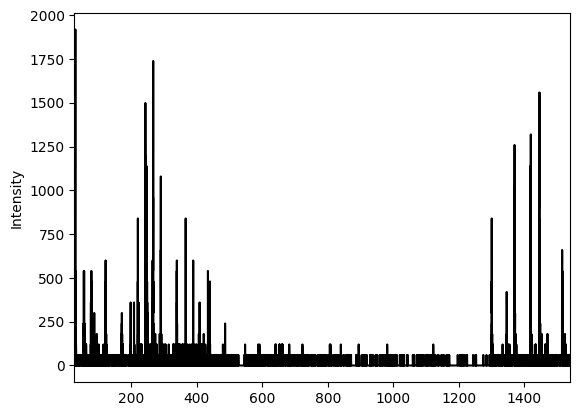

In [8]:
plot_intensity(seq,dt=1/60)

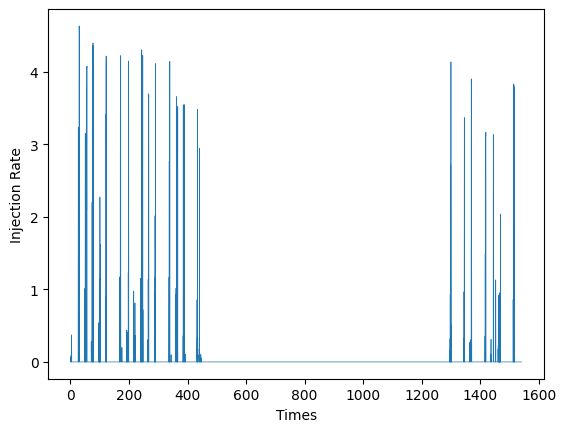

In [9]:
plt.xlabel('Times')
plt.ylabel('Injection Rate')
plt.plot(ts_time, ts,linewidth=0.5,color='tab:blue')

In [10]:
t_arr = seq.arrival_times.cpu().numpy()
T0 =0 
T = float(seq.arrival_times.max())
dt =1/60
edges = np.arange(T0, T + dt, dt)

counts, _ = np.histogram(t_arr, bins=edges)
lam = counts / dt

In [11]:
lam.max()

np.float64(1920.0)

In [12]:
indices = np.nonzero(lam > 500)[0]
indices/60

array([  29.7       ,   29.71666667,   29.75      ,   29.76666667,
         29.78333333,   29.81666667,   29.83333333,   29.85      ,
         29.86666667,   29.88333333,   29.9       ,   29.91666667,
         29.93333333,   29.95      ,   29.96666667,   29.98333333,
         30.        ,   30.01666667,   30.03333333,   30.05      ,
         30.06666667,   30.08333333,   30.1       ,   30.11666667,
         30.13333333,   30.15      ,   30.16666667,   30.18333333,
         30.2       ,   30.21666667,   30.28333333,   55.96666667,
         56.55      ,   56.63333333,   78.93333333,  122.41666667,
        220.8       ,  220.85      ,  220.88333333,  220.96666667,
        221.03333333,  243.11666667,  243.13333333,  243.2       ,
        243.25      ,  243.3       ,  243.31666667,  243.33333333,
        243.35      ,  243.36666667,  243.38333333,  243.4       ,
        243.41666667,  243.43333333,  243.45      ,  243.46666667,
        243.48333333,  243.5       ,  243.51666667,  243.53333

In [13]:
ts_count, edges = np.histogram(t_arr, bins=ts_time)
ts_ = (ts[1:]+ts[:-1])/2
ts_time_ = (ts_time[1:] + ts_time[:-1]) / 2
ts_ = ts_.numpy()
ts_time_ = ts_time_.numpy() 

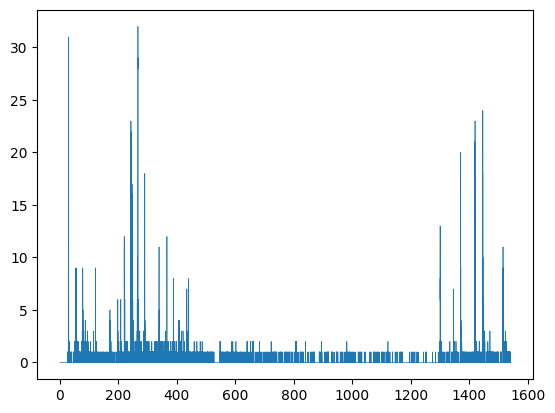

In [14]:
plt.plot(ts_time_, ts_count,linewidth=0.5,color='tab:blue')
# plt.plot(ts_time, ts)

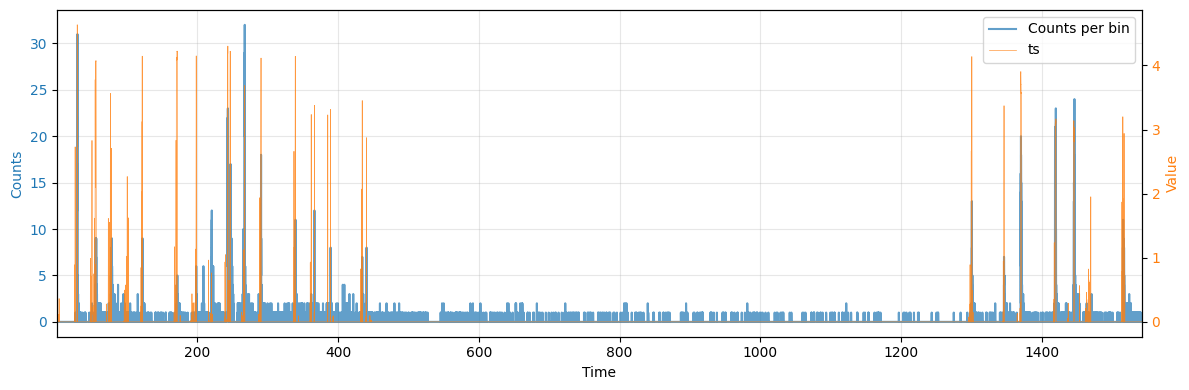

In [15]:
fig, ax1 = plt.subplots(figsize=(12, 4))
l1 = ax1.plot(ts_time[1:].numpy(), ts_count, label="Counts per bin", color="C0", alpha=0.7)
ax1.set_xlabel("Time")
ax1.set_ylabel("Counts", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.set_xlim(ts_time.min().item(), ts_time.max().item())
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
l2 = ax2.plot(ts_time_, ts_, label="ts", color="C1", alpha=0.8,linewidth=0.5)
ax2.set_ylabel("Value", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

lines = l1 + l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")
fig.tight_layout()

In [16]:
start = pd.to_datetime(catalog_ds.metadata['start_ts'])
end1 = pd.to_datetime("2018-10-25 13:28:00")
end2 = pd.to_datetime("2018-10-25 13:55:00")
end3 = pd.to_datetime("2018-10-17 14:00:00")
end4 = pd.to_datetime("2018-12-14 15:00:00")
diff_hour1 = (end1 - start) / pd.Timedelta(hours=1)
diff_hour2 = (end2 - start) / pd.Timedelta(hours=1)
diff_hour3 = (end3 - start) / pd.Timedelta(hours=1)
diff_hour4 = (end4 - start) / pd.Timedelta(hours=1)
print(diff_hour1)
print(diff_hour2)
print(diff_hour3)
print(diff_hour4)


245.46666666666667
245.91666666666666
54.0
1447.0


injection sum: 136.27781677246094, count sum: 1170.0, ratio: 8.585403169127039


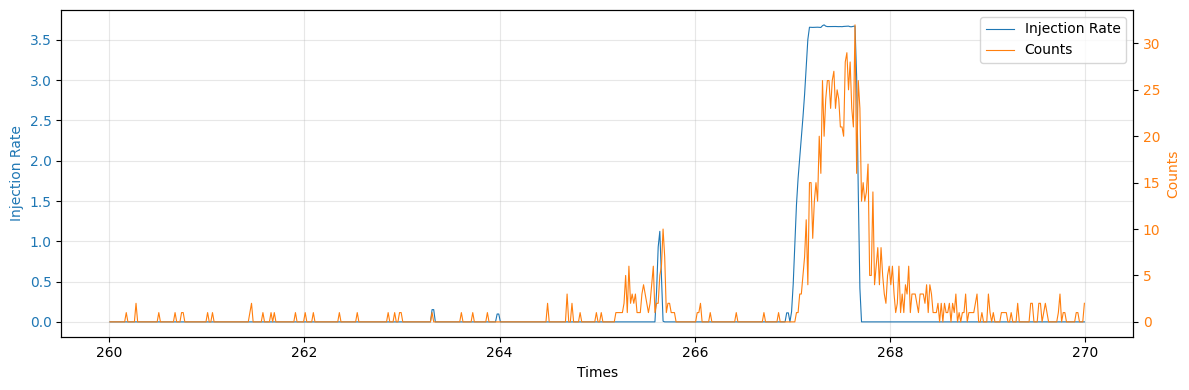

In [17]:
def plot_window(window_start=260, window_len=30, ts_time_=ts_time_, ts_=ts_, ts_count=ts_count, figsize=(12,4), ax=None):
    # convert tensors to numpy once for speed
    t = ts_time_
    inj = ts_
    counts = ts_count  # already numpy

    window_end = window_start + window_len
    mask = (t >= window_start) & (t <= window_end)
    # mask_ = np.roll(mask, -60)

    if ax is None:
        fig, ax1 = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
        ax1 = ax

    l1 = ax1.plot(t[mask], inj[mask], label="Injection Rate", color="C0", linewidth=0.8)
    ax1.set_xlabel("Times")
    ax1.set_ylabel("Injection Rate", color="C0")
    ax1.tick_params(axis="y", labelcolor="C0")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    l2 = ax2.plot(t[mask], counts[mask], label="Counts", color="C1", linewidth=0.8) 
    ax2.set_ylabel("Counts", color="C1")
    ax2.tick_params(axis="y", labelcolor="C1")

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper right")
    fig.tight_layout()

    inj_sum = float(inj[mask].sum())
    count_sum = float(counts[mask].sum())
    ratio = count_sum / inj_sum if inj_sum != 0 else float("inf")

    return {"fig": fig, "ax1": ax1, "ax2": ax2, "inj_sum": inj_sum, "count_sum": count_sum, "ratio": ratio}


res = plot_window(window_start=260, window_len=10)
print(f"injection sum: {res['inj_sum']}, count sum: {res['count_sum']}, ratio: {res['ratio']}")

## Find the base points of the peaks

In [18]:
ts_.shape ,ts_time_.shape, ts_count.shape

((92434,), (92434,), (92434,))

找到 60 个符合条件的局部极大值。
索引: [ 1555  1735  2853  2919  2988  3154  3262  3328  4381  4467  4555  4644
  5868  5992  6099  7166  7269 10011 10073 10177 10242 11797 11869 12913
 13173 14356 14564 14667 14765 15882 15983 17284 17392 20195 20320 21587
 21668 21940 23075 23315 25895 26014 26382 77799 77946 80629 80689 82121
 84972 85050 85111 86636 86697 87124 87894 88009 88082 90738 90814 90921]
数值: [2.730082   4.6337767  0.99134076 0.70635414 2.8295803  0.75
 3.7785392  4.073419   1.6129249  1.5516667  3.564      2.7076666
 0.575685   2.2670841  1.6221738  0.8466667  4.145      1.1713084
 0.5711625  4.120475   4.2226934  1.1357713  4.1498194  0.9640089
 0.7646083  1.0487742  4.302566   0.6517953  4.2220516  1.1240048
 3.6874413  1.9365909  4.114594   2.6604018  4.1417     0.92573464
 3.2348518  3.3772876  3.2285683  3.3144898  0.8270594  3.4520235
 2.8732302  0.89201236 4.1382833  0.9480132  3.372099   3.9043677
 1.234657   3.1087685  3.1671765  3.1348028  1.882247   0.5659015
 0.8248193  0.623

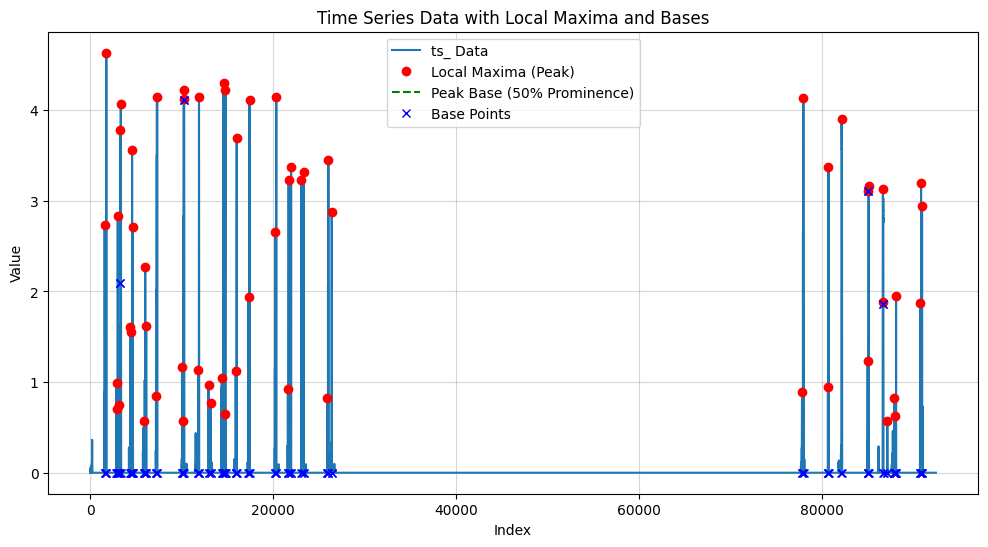

In [19]:
import numpy as np
from scipy.signal import find_peaks, peak_widths
import matplotlib.pyplot as plt

# # --- 1. 模拟数据 (替换为您的 ts_ 实际数据) ---
# # 形状 (92375,) 是一个很长的序列，这里我们用一个较短的序列来模拟
# # 模拟一个包含几个清晰峰值和噪声的时间序列
# np.random.seed(42)  # 设置随机种子以保证结果可重复
# N = 1000 # 模拟数据点数
# # 创建基线数据
# ts_base = 5 + np.sin(np.linspace(0, 10 * np.pi, N))
# # 添加几个主要的峰值
# ts_peaks = np.zeros(N)
# ts_peaks[100:200] = np.hanning(100) * 15 # 第一个峰
# ts_peaks[350:450] = np.hanning(100) * 8  # 第二个峰 (较低)
# ts_peaks[600:700] = np.hanning(100) * 20 # 第三个峰 (最高)
# # 添加少量噪声
# ts_noise = np.random.normal(0, 0.5, N)

# # 最终的模拟 ts_ 数据
# ts_ = ts_base + ts_peaks + ts_noise
# # 确保 ts_ 是一个 NumPy 数组
# ts_ = np.array(ts_) 


peaks_indices, properties = find_peaks(
    ts_, 
    height=0.5, 
    distance=60,
)

local_maxima_values = ts_[peaks_indices]
print(f"找到 {len(peaks_indices)} 个符合条件的局部极大值。")
print(f"索引: {peaks_indices}")
print(f"数值: {local_maxima_values}")
print("-" * 30)


# --- 3. 获取 Left Bases 和 Right Bases ---
# 使用 peak_widths 函数，传入数据和峰值索引
# 参数说明:
#   rel_height=0.5: 在峰高 (峰值到相邻谷底的高度差) 的 50% 处计算宽度和基座
widths_results = peak_widths(
    x=ts_, 
    peaks=peaks_indices, 
    rel_height=1
)

# widths_results 包含四个元素:
# (widths, width_heights, left_ips, right_ips)

widths, width_heights, left_bases_float, right_bases_float = widths_results

left_bases = np.round(left_bases_float).astype(int)
right_bases = np.round(right_bases_float).astype(int)

print(f"--- 基座 (Bases) 结果 ---")
print(f"左基座 (left_bases) 浮点索引: {left_bases_float}")
print(f"右基座 (right_bases) 浮点索引: {right_bases_float}")
print(f"左基座 (left_bases) 整数索引: {left_bases}")
print(f"右基座 (right_bases) 整数索引: {right_bases}")
print("-" * 30)


# --- 4. 绘图展示 (可视化结果) ---
# 可视化是验证峰值查找结果的最佳方式
plt.figure(figsize=(12, 6))
plt.plot(ts_, label='ts_ Data')

plt.plot(peaks_indices, local_maxima_values, "o", color='red', label='Local Maxima (Peak)')

for i in range(len(peaks_indices)):
    plt.hlines(
        y=width_heights[i], 
        xmin=left_bases_float[i], 
        xmax=right_bases_float[i], 
        color='green', 
        linestyle='--', 
        label='Peak Base (50% Prominence)' if i == 0 else "" 
    )

    plt.plot(left_bases_float[i], width_heights[i], "x", color='blue')
    plt.plot(right_bases_float[i], width_heights[i], "x", color='blue', label='Base Points' if i == 0 else "")


plt.title('Time Series Data with Local Maxima and Bases')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

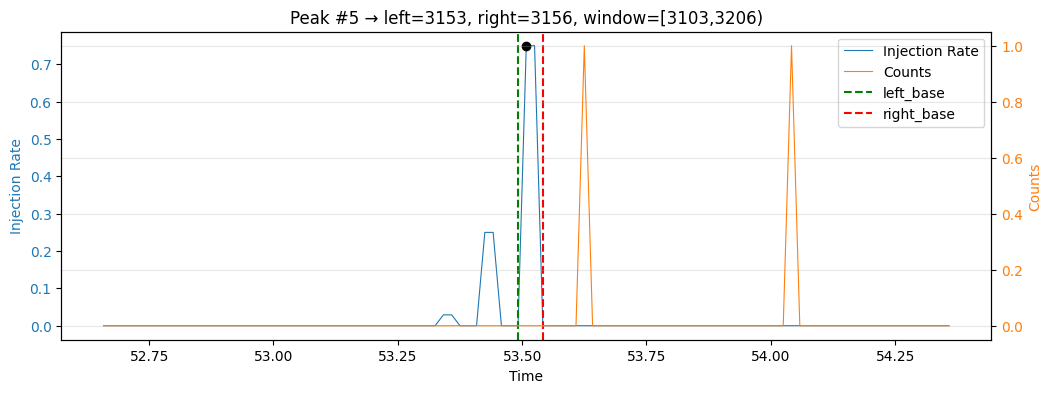

In [20]:
index = 5
offset = 50

# validate index
if index < 0 or index >= len(left_bases):
    raise IndexError(f"index {index} out of range (0..{len(left_bases)-1})")

lb = int(left_bases[index])
rb = int(right_bases[index])
start = max(0, lb - offset)
end = min(len(ts_), rb + offset)

x = ts_time_[start:end]

fig, ax1 = plt.subplots(figsize=(12,4))
ln1 = ax1.plot(x, ts_[start:end], color='tab:blue', label='Injection Rate', linewidth=0.8)
ax1.set_xlabel('Time')
ax1.set_ylabel('Injection Rate', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ln2 = ax2.plot(x, ts_count[start:end], color='tab:orange', label='Counts', linewidth=0.8)
ax2.set_ylabel('Counts', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.axvline(ts_time_[lb], color='green', linestyle='--', label='left_base')
ax1.axvline(ts_time_[rb], color='red', linestyle='--', label='right_base')

peak_idx = peaks_indices[index]
if start <= peak_idx < end:
    ax1.plot(ts_time_[peak_idx], ts_[peak_idx], 'o', color='black', label='peak')

# combine legends from both axes
lines = ln1 + ln2 + [ax1.lines[-3], ax1.lines[-2]]  # include the vlines and peak if present
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title(f'Peak #{index} → left={lb}, right={rb}, window=[{start},{end})')
plt.grid(alpha=0.3)
plt.show()